# Setting up a simple example using an articulated robot

In [8]:
import sys
from pathlib import Path


# Define paths
REPO_ROOT = Path.cwd().parent               # Repo root (ikp-sbl)
LECTURE_EXAMPLES = REPO_ROOT / "lecture_examples"

# Add BOTH to sys.path
for path in [str(REPO_ROOT), str(LECTURE_EXAMPLES)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from lecture_examples.IPPlanarManipulator import PlanarJoint, PlanarRobot
from IPEnvironmentKin import KinChainCollisionChecker, planarRobotVisualize, animateSolution
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

from planners.SBL import BidirectionalSBL
from modules import IPVISsbl

obst = dict()
obst["obs1"] = LineString([(-2, 0), (-0.8, 0)]).buffer(0.5)
obst["obs2"] = LineString([(2, 0), (2, 1)]).buffer(0.2)
obst["obs3"] = LineString([(-1, 2), (1, 2)]).buffer(0.1)

# 2-DoF

In [9]:
r = PlanarRobot(n_joints=2)
environment = KinChainCollisionChecker(r, obst,fk_resolution=.2)

Draw start and goal position of robot within the environment

In [10]:
start_joint_pos = [2.0, 0.5]
end_joint_pos = [-2.0, -0.5]

start = start_joint_pos
goal  = end_joint_pos

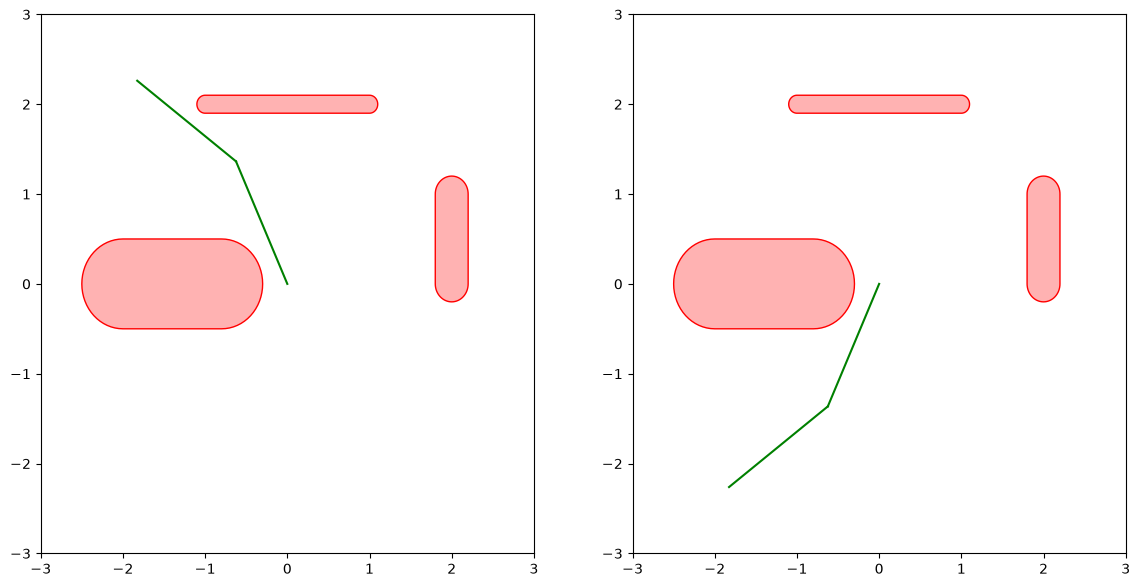

In [11]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(goal)
planarRobotVisualize(r, ax2)

In [12]:
config = {} #BidirectionalSBL.DEFAULT_CONFIG.copy()
config["iterations"] = 100
config["eta"] = 2.0

planner = BidirectionalSBL(environment)


In [13]:
## plan path from start to goal
solution = planner.planPath(start, goal, config)
print(solution)

  0%|          | 0/100 [00:00<?, ?it/s]

 20%|██        | 20/100 [00:05<00:21,  3.75it/s]

[Node(start, [2.  0.5]), Node(start, [1.89468048 0.56732607]), Node(start, [1.6083219  1.26050625]), Node(start, [1.65090995 1.39970744]), Node(start, [1.54772979 1.44454162]), Node(start, [1.37635287 1.52060872]), Node(start, [0.05478316 2.74267807]), Node(goal, [-0.23835986  2.43907438]), Node(goal, [-1.00506646  1.96773481]), Node(goal, [-1.16763432  1.52695803]), Node(goal, [-1.65961243  0.96086834]), Node(goal, [-2.  -0.5])]


AttributeError: 'BidirectionalSBL' object has no attribute 'graph'

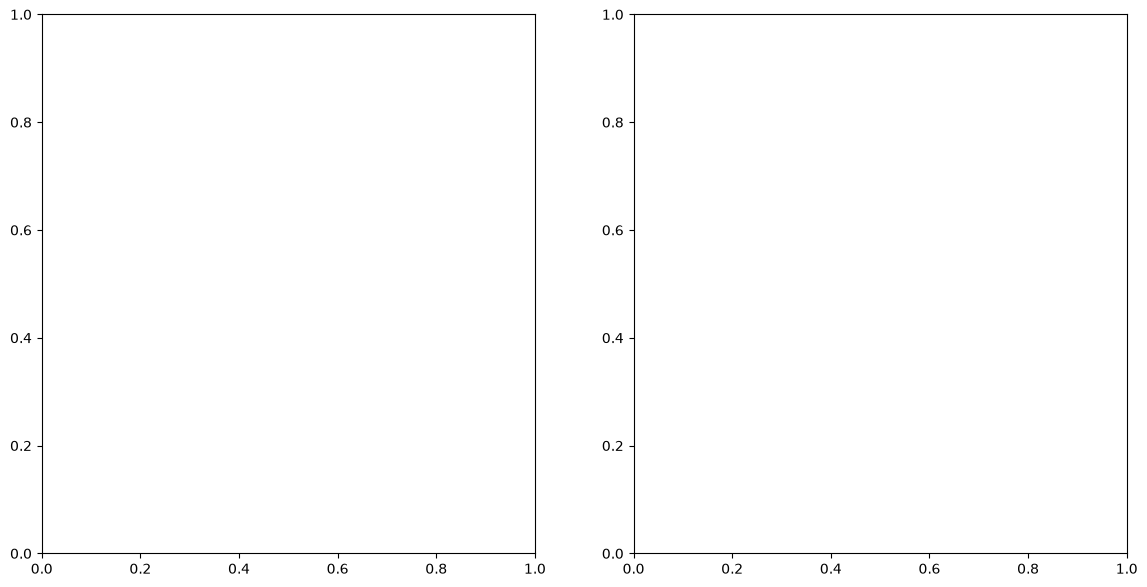

In [ ]:
import networkx as nx

# in planners/SBL.py

class BidirectionalSBL:
    def planPath(self, start, goal, config=None):
        # Run the planner search to find a path from start to goal.
        # The result is a list of nodes representing the solution path.
        solution = self._run_search(start, goal, config)

        # Build a graph only once, when the planner first returns a solution.
        # This avoids recreating the graph on every call to planPath.
        if getattr(self, "graph", None) is None:
            self.graph = self._build_solution_graph(solution)

        return solution

    @staticmethod
    def _node_state(node):
        # Try several common attribute names that may store the node's state.
        # This makes the helper robust for different node implementations.
        for attr in ("state", "config", "joint_state", "q"):
            value = getattr(node, attr, None)
            if value is not None:
                return value

        # If none of the expected attributes exist, just use the node itself.
        return node

    def _build_solution_graph(self, solution):
        # Create a NetworkX graph to represent the solution path.
        g = nx.Graph()

        # Add each solution node as a graph node.
        # Store the node's state as a graph attribute for later inspection.
        for i, node in enumerate(solution):
            g.add_node(i, state=self._node_state(node))

            # Connect consecutive nodes so the graph forms a path chain.
            if i > 0:
                g.add_edge(i - 1, i)

        return g

In [ ]:
# 4-DoF

In [ ]:
r = PlanarRobot(n_joints=4)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = BidirectionalSBL(environment)

In [ ]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

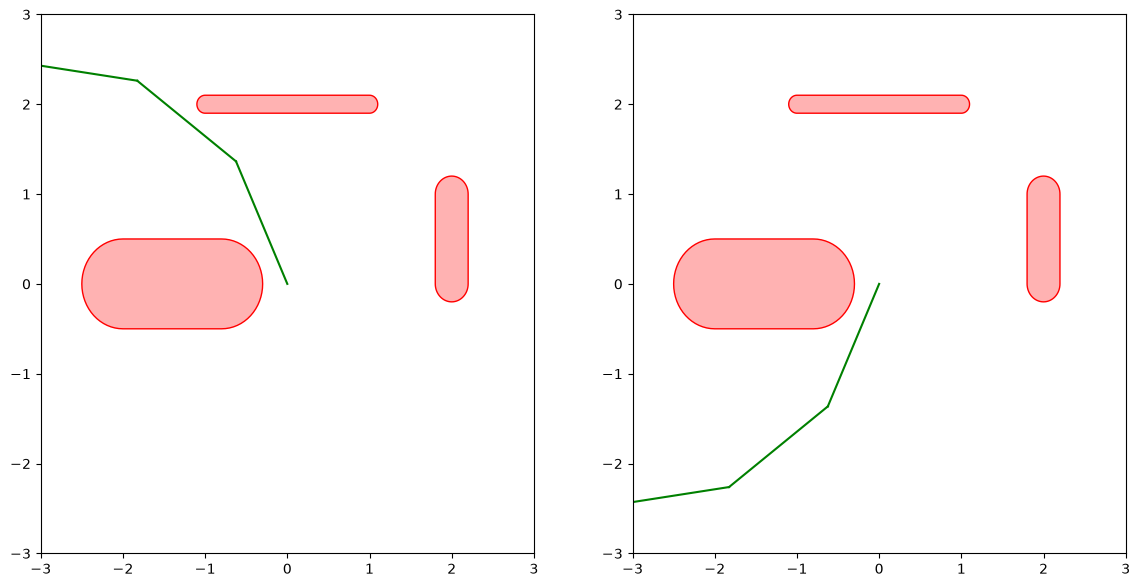

In [ ]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [ ]:
solution = planner.planPath(start, goal, config)
print(solution)

100%|██████████| 100/100 [34:09<00:00, 20.50s/it]

[]


IndexError: list index out of range

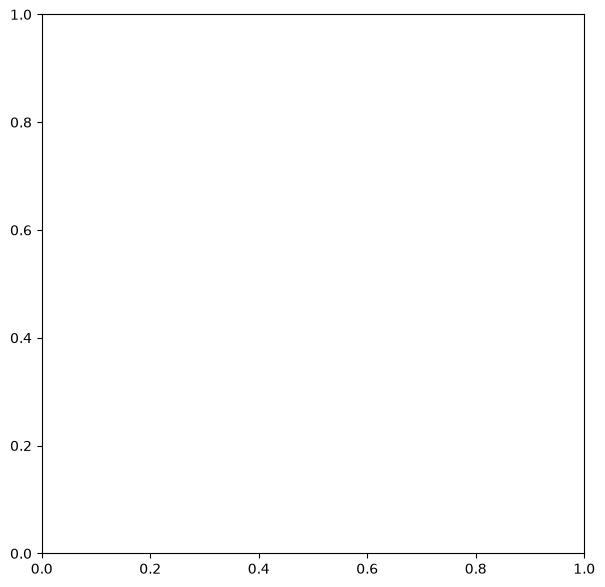

In [ ]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)

## 6-DoF

In [ ]:
r = PlanarRobot(n_joints=6)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = BidirectionalSBL(environment)

In [ ]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

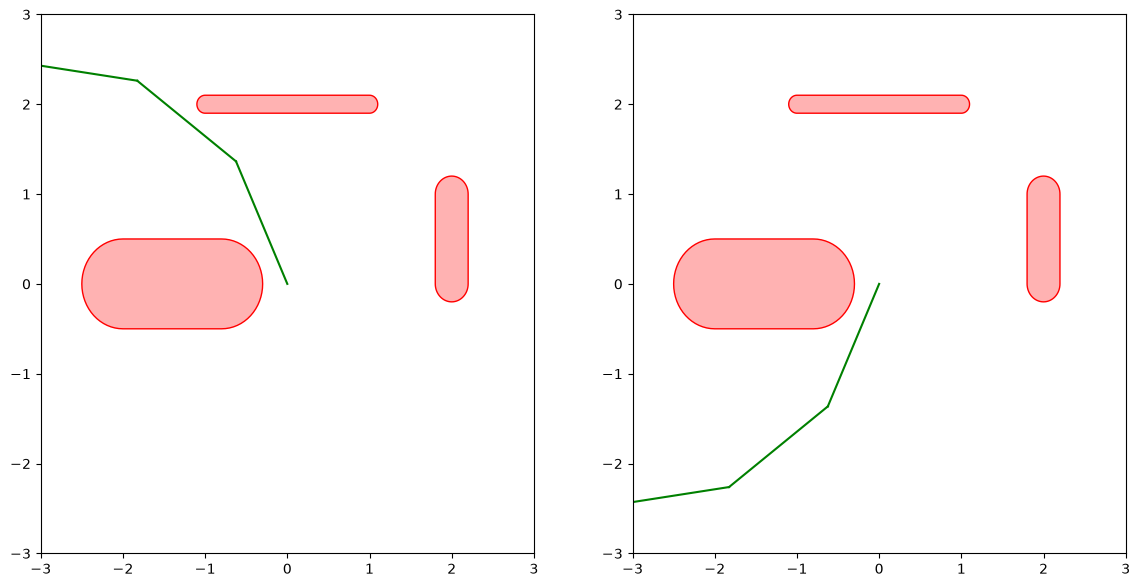

In [ ]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [ ]:
solution = planner.planPath(start, goal, config)
print(solution)

  1%|          | 1/100 [02:47<4:36:19, 167.47s/it]


KeyboardInterrupt: 

In [ ]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)